In [146]:
path = r"C:\Users\rqm\OneDrive\Documentos\ciencia de datos\RegrecionesLineales\repeticion\data\hotel_reservations_pricing_revenue.csv"

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [148]:
df = pd.read_csv(path)

df.head()

C:\Users\rqm\AppData\Local\Temp\ipykernel_24528\2498738941.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,id,is_confirmed,is_payment_verified,is_fulfilled,state,registered_date,date_from,date_to,adult_count,child_count,...,cost_of_rooms_eur,gross_booking_revenue_eur,is_credit_booking,os,sum_room_adult,sum_room_children,sum_room_extra_bed,room_id,book_from_recommendation,city_id
0,88262740,1,1,1,draft,2022-08-08 08:05:34.585000,2022-08-25,2022-08-26,0,0,...,161.632653,183.673469,0,desktop,2,1.0,1.0,0,0,0
1,88262391,1,1,1,draft,2022-08-08 07:21:02.876000,2022-08-09,2022-08-10,0,0,...,81.632653,89.795918,0,desktop,2,1.0,0.0,1,0,1
2,88261688,1,1,1,draft,2022-08-08 07:07:57.103000,2022-08-11,2022-08-13,0,0,...,468.367347,551.020408,0,desktop,3,1.0,1.0,2,0,2
3,88261666,1,1,1,draft,2022-08-08 06:40:20.899000,2022-08-15,2022-08-16,0,0,...,1240.816327,1318.367347,0,desktop,3,1.0,1.0,3,0,3
4,88261194,1,1,1,draft,2022-08-08 04:49:46.954000,2022-08-10,2022-08-15,0,0,...,119.387755,132.653061,0,desktop,2,1.0,0.0,4,0,4


In [149]:
df.tail()

,id,is_confirmed,is_payment_verified,is_fulfilled,state,registered_date,date_from,date_to,adult_count,child_count,...,cost_of_rooms_eur,gross_booking_revenue_eur,is_credit_booking,os,sum_room_adult,sum_room_children,sum_room_extra_bed,room_id,book_from_recommendation,city_id
47341,88265241,1,1,1,draft,2022-08-08 10:06:16.405000,2022-08-23,2022-08-26,0,0,...,592.653061,673.469388,0,desktop,3,1.0,1.0,176,1,0
47342,88265042,1,1,1,draft,2022-08-08 09:58:51.116000,2022-08-16,2022-08-19,0,0,...,165.306122,183.673469,0,desktop,4,2.0,0.0,4,0,4
47343,88264813,1,1,1,draft,2022-08-08 09:14:48.467000,2022-08-10,2022-08-11,0,0,...,231.663265,238.775510,0,desktop,2,1.0,0.0,751,0,6
47344,88264578,1,1,1,draft,2022-08-08 08:55:51.322000,2022-08-10,2022-08-11,0,0,...,252.734694,263.673469,0,desktop,2,1.0,1.0,1778,0,2
47345,88262796,1,1,1,draft,2022-08-08 08:51:15.715000,2022-09-14,2022-09-16,0,0,...,236.734694,253.061224,0,desktop,2,1.0,0.0,1,0,1


In [150]:
df.isnull().sum()

id                                0
is_confirmed                      0
is_payment_verified               0
is_fulfilled                      0
state                             0
registered_date                   0
date_from                         0
date_to                           0
adult_count                       0
child_count                       0
infant_count                      0
travel_type                   47343
price                             0
discount                          0
final_price                       0
buy_price                         0
reservation_type                  0
cancellation_state            47346
payment_currency_unit             0
currency_book                     0
original_sell_price             477
utm_campaign                  39350
is_utm_campaign                   0
total_room_nights                 0
booking_price                     0
booking_date                      0
user_id                           0
hotel_id                    

In [151]:
df.describe()

,id,is_confirmed,is_payment_verified,is_fulfilled,adult_count,child_count,infant_count,price,discount,final_price,...,net_commission_revenue_eur,cost_of_rooms_eur,gross_booking_revenue_eur,is_credit_booking,sum_room_adult,sum_room_children,sum_room_extra_bed,room_id,book_from_recommendation,city_id
count,4.734600e+04,47346.0,47346.0,47346.0,47346.0,47346.0,47346.0,4.734600e+04,4.734600e+04,4.734600e+04,...,47346.000000,47346.000000,47346.000000,47346.000000,47346.000000,47331.000000,47345.000000,47346.000000,47346.000000,47346.000000
mean,5.273589e+07,1.0,1.0,1.0,0.0,0.0,0.0,3.165822e+06,1.284216e+05,3.035675e+06,...,53.636123,565.889385,619.525508,0.002978,2.530710,0.838837,0.416559,1394.560808,0.015693,10.046488
std,2.457427e+07,0.0,0.0,0.0,0.0,0.0,0.0,7.106318e+06,1.136916e+06,6.898168e+06,...,117.073694,1319.155711,1407.789386,0.054491,1.419326,0.603508,0.693331,1207.937200,0.124286,16.027739
min,1.000606e+07,1.0,1.0,1.0,0.0,0.0,0.0,3.400000e+04,-1.600000e+06,3.400000e+04,...,-1316.326531,5.551020,6.938776,0.000000,1.000000,0.000000,-2.000000,0.000000,0.000000,0.000000
25%,3.168335e+07,1.0,1.0,1.0,0.0,0.0,0.0,7.900000e+05,0.000000e+00,7.500000e+05,...,10.612245,133.795918,153.061224,0.000000,2.000000,1.000000,0.000000,393.000000,0.000000,1.000000
50%,5.268858e+07,1.0,1.0,1.0,0.0,0.0,0.0,1.596000e+06,0.000000e+00,1.520000e+06,...,25.235918,277.616327,310.204082,0.000000,2.000000,1.000000,0.000000,1050.000000,0.000000,3.000000
75%,7.391879e+07,1.0,1.0,1.0,0.0,0.0,0.0,3.360000e+06,0.000000e+00,3.240000e+06,...,58.775510,596.938776,661.224490,0.000000,3.000000,1.000000,1.000000,2108.000000,0.000000,11.000000
max,9.527730e+07,1.0,1.0,1.0,0.0,0.0,0.0,5.360000e+08,1.056000e+08,5.360000e+08,...,8765.306122,103918.367347,109387.755102,1.000000,60.000000,30.000000,29.000000,5110.000000,1.000000,138.000000


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47346 entries, 0 to 47345
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          47346 non-null  int64  
 1   is_confirmed                47346 non-null  int64  
 2   is_payment_verified         47346 non-null  int64  
 3   is_fulfilled                47346 non-null  int64  
 4   state                       47346 non-null  object 
 5   registered_date             47346 non-null  object 
 6   date_from                   47346 non-null  object 
 7   date_to                     47346 non-null  object 
 8   adult_count                 47346 non-null  int64  
 9   child_count                 47346 non-null  int64  
 10  infant_count                47346 non-null  int64  
 11  travel_type                 3 non-null      object 
 12  price                       47346 non-null  int64  
 13  discount                    473

In [153]:
df.shape

(47346, 42)

In [154]:
df.columns

Index(['id', 'is_confirmed', 'is_payment_verified', 'is_fulfilled', 'state',
       'registered_date', 'date_from', 'date_to', 'adult_count', 'child_count',
       'infant_count', 'travel_type', 'price', 'discount', 'final_price',
       'buy_price', 'reservation_type', 'cancellation_state',
       'payment_currency_unit', 'currency_book', 'original_sell_price',
       'utm_campaign', 'is_utm_campaign', 'total_room_nights', 'booking_price',
       'booking_date', 'user_id', 'hotel_id', 'hotel_rank', 'hotel_stars',
       'hotel_accommodation_type', 'net_commission_revenue_eur',
       'cost_of_rooms_eur', 'gross_booking_revenue_eur', 'is_credit_booking',
       'os', 'sum_room_adult', 'sum_room_children', 'sum_room_extra_bed',
       'room_id', 'book_from_recommendation', 'city_id'],
      dtype='object')

In [155]:
X =  df[["is_payment_verified","registered_date","adult_count", "child_count","total_room_nights","net_commission_revenue_eur"]]

y = df["final_price"]

In [156]:
numerics2  = X.select_dtypes(include = ["int64","float64"]).columns
categorics = X.select_dtypes(include = [object]).columns

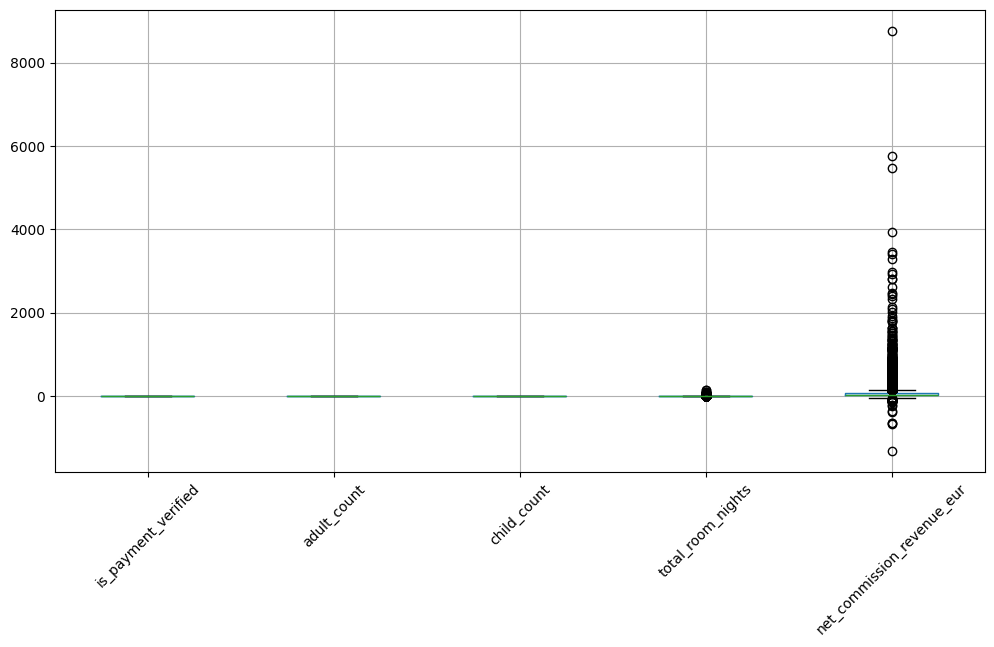

In [157]:
X[numerics2].boxplot(figsize=(12, 6))
plt.xticks(rotation = 45)
plt.show()

In [158]:

total_noches_media = np.mean(df["total_room_nights"])
print(f"Media de Noches: {total_noches_media}")

Media de Noches: 2.4093904448105437


In [159]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [160]:
#Duda---------
pipeline_numerics = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Datos dummy con onehotencoder
from sklearn.preprocessing import OneHotEncoder
pipeline_cat = Pipeline([ ('imputer', SimpleImputer(strategy = 'most_frequent')),
                         ('onehot',OneHotEncoder(handle_unknown = 'ignore'))
                         ])

#Unir los dos pipelines
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('numerics', pipeline_numerics, numerics2),
    ('categorics', pipeline_cat, categorics)
])

#Dividir los datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
#Regresion polinomial seria edad, BMI 
#Para crear transformacion polinomial
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


In [ ]:
pipeline_poly = Pipeline([
    ('preprocessor', preprocessor),
    ('polynomial', PolynomialFeatures(degree=1,  include_bias = False)),  # ==> No entiendo | degree |" interaction_only=True"
    ('model', LinearRegression()) 
])

In [179]:
print(X_train.shape)

(37876, 6)


In [180]:
#Entrenar el modelo
pipeline_poly.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('polynomial', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerics', ...), ('categorics', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [187]:
pred_ploy = pipeline_poly.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score

r2 = r2_score(y_test, pred_ploy)
mse = mean_squared_error(y_test, pred_ploy)
print(f"R2: {r2}")  
print(f"MSE: {mse}")

R2: 0.6438826793108333
MSE: 26262180007414.04


In [186]:
from  sklearn.linear_model import LinearRegression

pipeline_LR = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline_LR.fit(X_train, y_train)
pred_LR = pipeline_LR.predict(X_test)
#metricas
r2_LR = r2_score(y_test, pred_LR)
mse_LR = mean_squared_error(y_test, pred_LR)
print(f"R2: {r2_LR}")  
print(f"MSE: {mse_LR}")

R2: 0.6438826793108333
MSE: 26262180007414.04
